# IA – Aula 3 (Parte 2)
## Modelagem de Conforto Térmico com Decision Tree

### Objetivo
Treinar uma **Árvore de Decisão** para classificar conforto térmico e comparar com o sistema baseado em regras da Parte 1.

### Fundamentação — Norma ASHRAE 55
A norma **ASHRAE Standard 55** (American Society of Heating, Refrigerating and Air-Conditioning Engineers) define zonas de conforto térmico com base em fatores ambientais e pessoais. Os principais parâmetros são:

| Parâmetro | Descrição |
|---|---|
| Temperatura do ar (Tair) | Temperatura de bulbo seco (°C) |
| Umidade relativa (RH) | Umidade relativa do ar (%) |
| Velocidade do ar (Vair) | Velocidade do ar na zona ocupada (m/s) |
| CLO | Isolamento térmico da vestimenta (clo) |
| MET | Taxa metabólica do ocupante (met) |

A escala **TSV** (Thermal Sensation Vote) varia de **-3** (frio) a **+3** (quente):

| TSV | Sensação |
|---|---|
| -3 | Frio |
| -2 | Fresco |
| -1 | Levemente fresco |
|  0 | Neutro (confortável) |
| +1 | Levemente quente |
| +2 | Quente |
| +3 | Muito quente |

A zona de conforto ASHRAE 55 considera aceitável a faixa de **20°C a 26°C** com umidade relativa entre **30% e 60%** para atividades sedentárias típicas.

**Referências:**
- ASHRAE Standard 55-2020 — Thermal Environmental Conditions for Human Occupancy
- ASHRAE Global Thermal Comfort Database II (Zenodo, 10.618 registros)
- Dataset: Thermal Sensation Classification based on ASHRAE DB II (Zenodo, 2024)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

np.random.seed(42)

## 1. Geração do Dataset Sintético

Simulamos **2.000 amostras** com distribuições realistas baseadas nos intervalos do ASHRAE Global Thermal Comfort Database II:
- **Tair:** 5°C a 45°C
- **RH:** 10% a 95%

As classes são simplificações da escala TSV agrupadas em 5 categorias.

**Ruído:** 10% dos rótulos são trocados aleatoriamente para simular a subjetividade real — pessoas diferentes sentem de formas diferentes nas mesmas condições ambientais.

In [2]:
n = 2000

temperatura = np.round(np.random.uniform(5, 45, n), 1)
umidade = np.round(np.random.uniform(10, 95, n), 1)


def rotular_ashrae(temp, rh):
    """Rotulação inspirada na ASHRAE 55 + extensões para extremos.
    Zona de conforto: 20-26°C e 30-60% RH.
    Faixas externas baseadas na escala TSV."""
    if temp < 15:
        return 'Frio'
    elif temp > 33:
        return 'Quente'
    elif rh < 25:
        return 'Seco'
    elif rh > 75:
        return 'Úmido'
    elif 20 <= temp <= 26 and 30 <= rh <= 60:
        return 'Confortável'
    elif temp < 20:
        return 'Frio'
    elif temp > 26:
        return 'Quente'
    elif rh < 30:
        return 'Seco'
    elif rh > 60:
        return 'Úmido'
    else:
        return 'Confortável'


labels = [rotular_ashrae(t, u) for t, u in zip(temperatura, umidade)]

# Adicionar ruído: 10% dos rótulos são trocados aleatoriamente
# (simula subjetividade — pessoas sentem diferente nas mesmas condições)
classes_possiveis = ['Frio', 'Quente', 'Seco', 'Úmido', 'Confortável']
noise_mask = np.random.random(n) < 0.10
labels_noisy = [
    np.random.choice([c for c in classes_possiveis if c != lbl])
    if flip else lbl
    for lbl, flip in zip(labels, noise_mask)
]

df = pd.DataFrame({
    'temperatura': temperatura,
    'umidade': umidade,
    'classe': labels_noisy
})

print(f'Total de amostras: {len(df)}')
print(f'\nDistribuição das classes:')
print(df['classe'].value_counts())

Total de amostras: 2000

Distribuição das classes:
classe
Quente         775
Frio           624
Úmido          271
Seco           198
Confortável    132
Name: count, dtype: int64


In [3]:
df.head(10)

,temperatura,umidade,classe
0,20.0,32.2,Confortável
1,43.0,31.0,Quente
2,34.3,87.0,Quente
3,28.9,31.2,Quente
4,11.2,33.1,Frio
5,11.2,74.5,Frio
6,7.3,48.2,Frio
7,39.6,76.0,Quente
8,29.0,15.6,Seco
9,33.3,51.4,Frio


## 2. Visualização Exploratória

Scatter plot das amostras coloridas por classe, com a zona de conforto ASHRAE destacada.

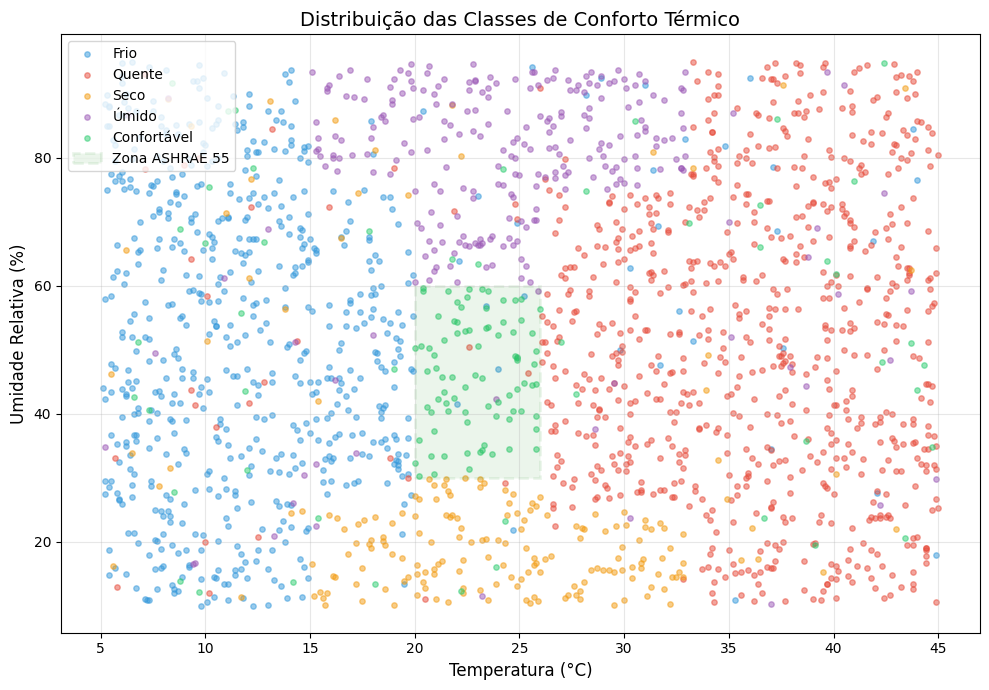

In [4]:
cores = {
    'Frio': '#3498db',
    'Quente': '#e74c3c',
    'Seco': '#f39c12',
    'Úmido': '#9b59b6',
    'Confortável': '#2ecc71'
}

fig, ax = plt.subplots(figsize=(10, 7))

for classe, cor in cores.items():
    subset = df[df['classe'] == classe]
    ax.scatter(subset['temperatura'], subset['umidade'],
               c=cor, label=classe, alpha=0.5, s=15)

# Zona de conforto ASHRAE 55
rect = plt.Rectangle((20, 30), 6, 30, linewidth=2,
                      edgecolor='green', facecolor='green',
                      alpha=0.08, linestyle='--',
                      label='Zona ASHRAE 55')
ax.add_patch(rect)

ax.set_xlabel('Temperatura (°C)', fontsize=12)
ax.set_ylabel('Umidade Relativa (%)', fontsize=12)
ax.set_title('Distribuição das Classes de Conforto Térmico', fontsize=14)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Treinamento da Árvore de Decisão

In [5]:
X = df[['temperatura', 'umidade']]
y = df['classe']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f'Treino: {len(X_train)} amostras')
print(f'Teste:  {len(X_test)} amostras')

Treino: 1400 amostras
Teste:  600 amostras


In [6]:
tree_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred = tree_model.predict(X_test)

print(f'Acurácia: {accuracy_score(y_test, y_pred):.4f}')
print(f'\nClassification Report:\n')
print(classification_report(y_test, y_pred))

Acurácia: 0.8733

Classification Report:

              precision    recall  f1-score   support

 Confortável       0.80      0.60      0.69        40
        Frio       0.85      0.91      0.88       187
      Quente       0.90      0.94      0.92       233
        Seco       0.84      0.78      0.81        59
       Úmido       0.89      0.80      0.84        81

    accuracy                           0.87       600
   macro avg       0.86      0.81      0.83       600
weighted avg       0.87      0.87      0.87       600



## 4. Matriz de Confusão

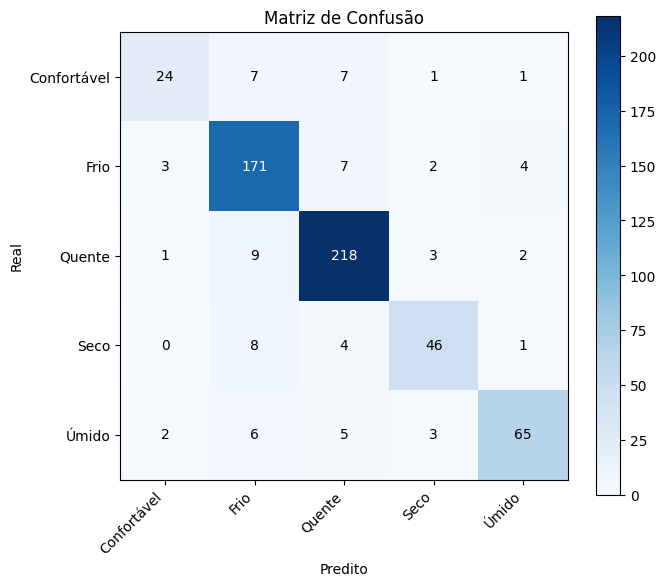

In [7]:
classes_unicas = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=classes_unicas)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.set_xticks(range(len(classes_unicas)))
ax.set_yticks(range(len(classes_unicas)))
ax.set_xticklabels(classes_unicas, rotation=45, ha='right')
ax.set_yticklabels(classes_unicas)
ax.set_xlabel('Predito')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão')

for i in range(len(classes_unicas)):
    for j in range(len(classes_unicas)):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.colorbar(im)
plt.tight_layout()
plt.show()

## 5. Visualização da Árvore

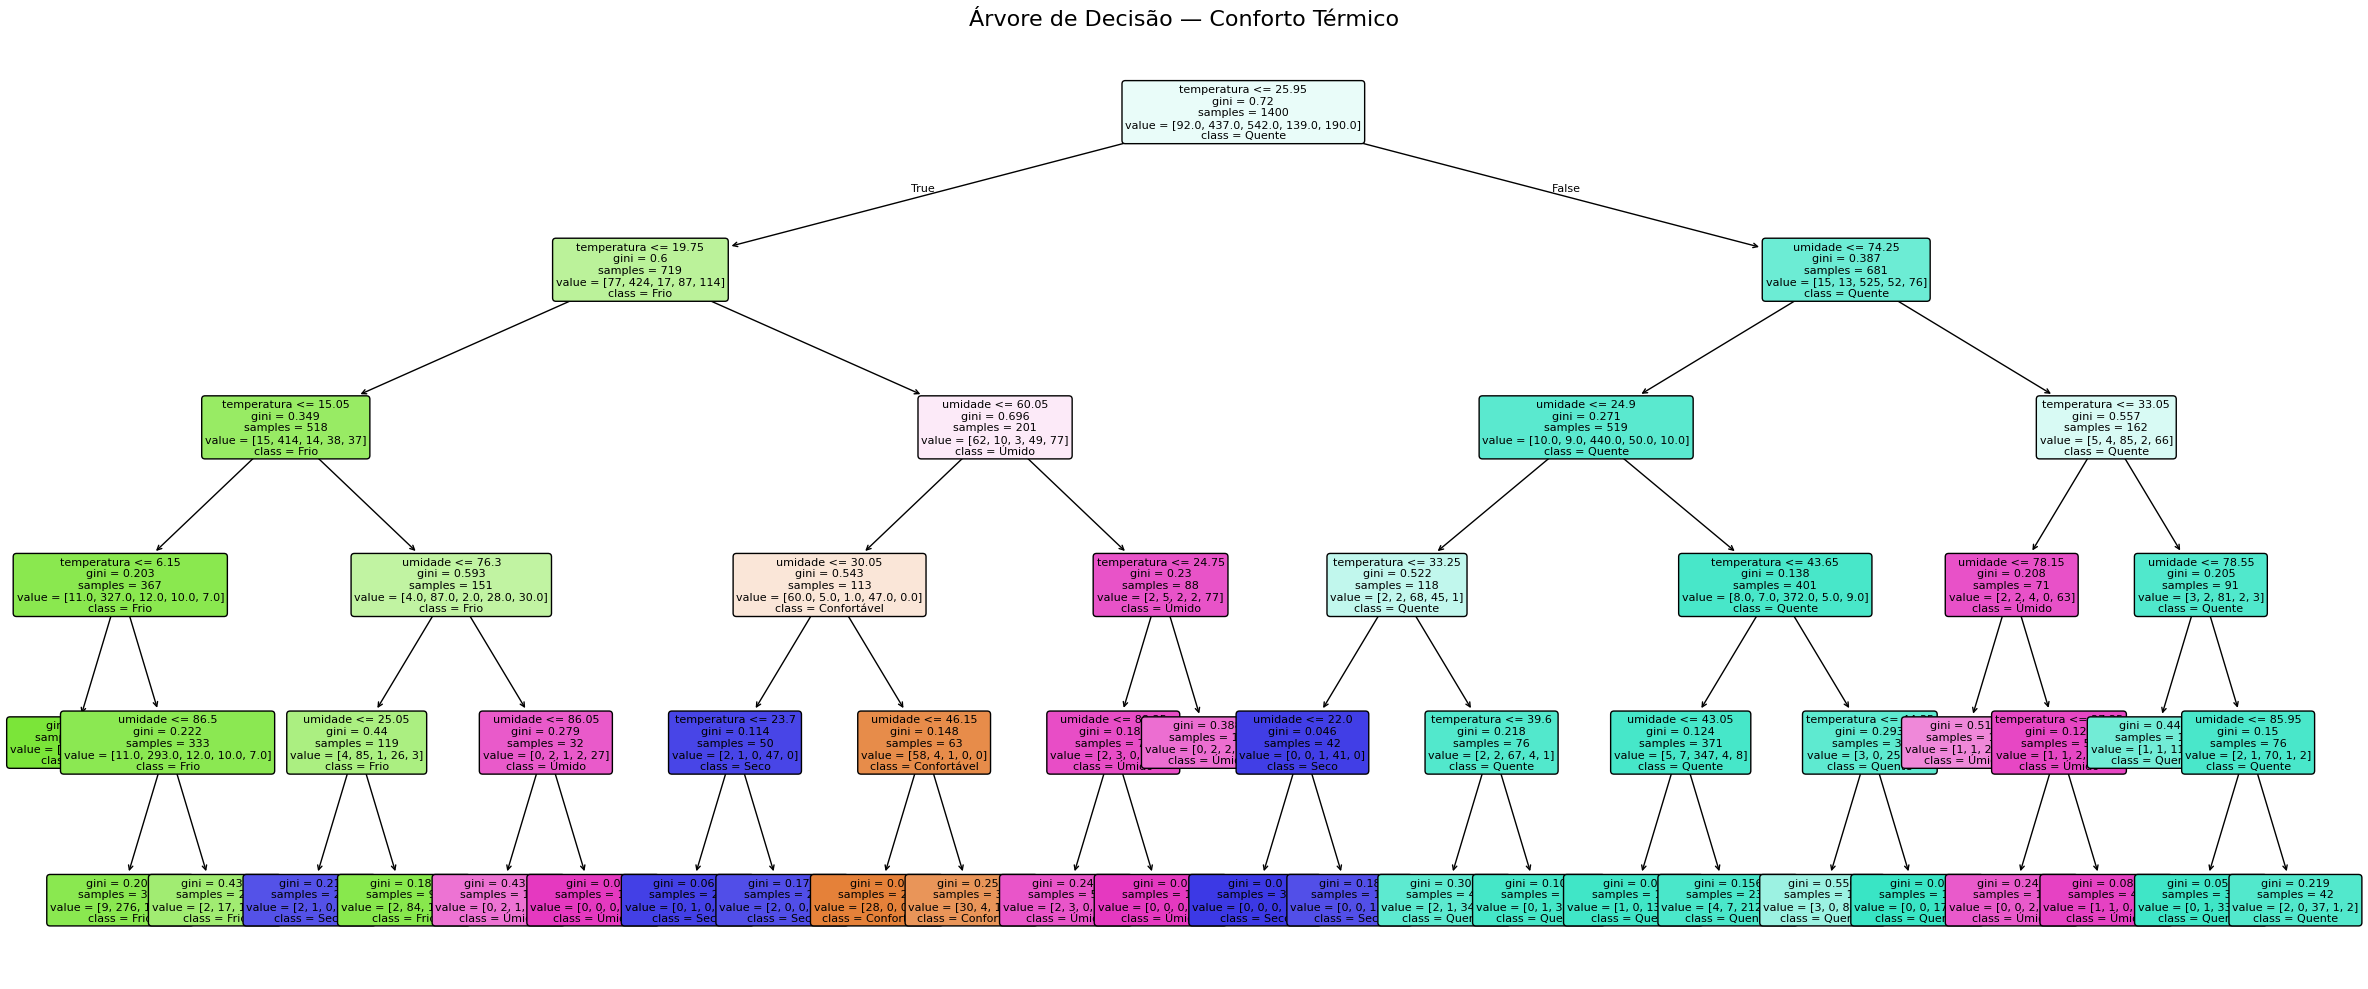

In [8]:
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(
    tree_model,
    feature_names=['temperatura', 'umidade'],
    class_names=classes_unicas,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax
)
ax.set_title('Árvore de Decisão — Conforto Térmico', fontsize=16)
plt.tight_layout()
plt.show()

In [9]:
print('Regras extraídas da árvore:\n')
print(export_text(tree_model,
                  feature_names=['temperatura', 'umidade'],
                  class_names=classes_unicas))

Regras extraídas da árvore:

|--- temperatura <= 25.95
|   |--- temperatura <= 19.75
|   |   |--- temperatura <= 15.05
|   |   |   |--- temperatura <= 6.15
|   |   |   |   |--- class: Frio
|   |   |   |--- temperatura >  6.15
|   |   |   |   |--- umidade <= 86.50
|   |   |   |   |   |--- class: Frio
|   |   |   |   |--- umidade >  86.50
|   |   |   |   |   |--- class: Frio
|   |   |--- temperatura >  15.05
|   |   |   |--- umidade <= 76.30
|   |   |   |   |--- umidade <= 25.05
|   |   |   |   |   |--- class: Seco
|   |   |   |   |--- umidade >  25.05
|   |   |   |   |   |--- class: Frio
|   |   |   |--- umidade >  76.30
|   |   |   |   |--- umidade <= 86.05
|   |   |   |   |   |--- class: Úmido
|   |   |   |   |--- umidade >  86.05
|   |   |   |   |   |--- class: Úmido
|   |--- temperatura >  19.75
|   |   |--- umidade <= 60.05
|   |   |   |--- umidade <= 30.05
|   |   |   |   |--- temperatura <= 23.70
|   |   |   |   |   |--- class: Seco
|   |   |   |   |--- temperatura >  23.70
|   |

## 6. Superfície de Decisão

Visualização das regiões que a árvore aprendeu vs. a zona de conforto ASHRAE.

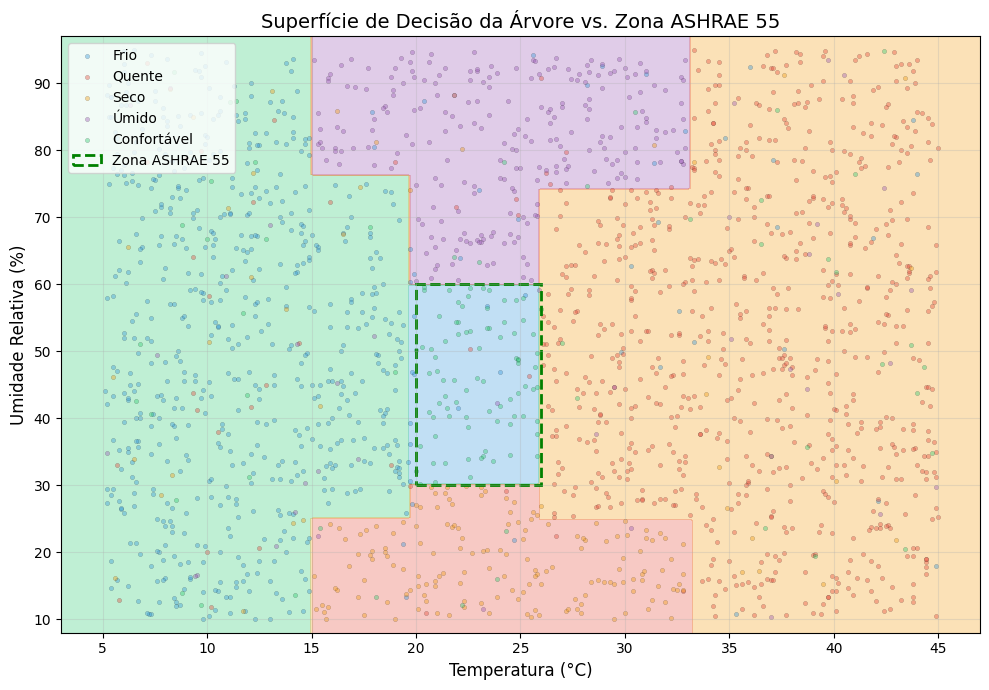

In [10]:
from matplotlib.colors import ListedColormap

# Grid de predição
t_range = np.linspace(3, 47, 300)
u_range = np.linspace(8, 97, 300)
tt, uu = np.meshgrid(t_range, u_range)
grid = pd.DataFrame({'temperatura': tt.ravel(), 'umidade': uu.ravel()})
grid_pred = tree_model.predict(grid)

# Mapear classes para inteiros
classe_map = {c: i for i, c in enumerate(classes_unicas)}
grid_int = np.array([classe_map[c] for c in grid_pred]).reshape(tt.shape)

cores_list = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6']
cmap = ListedColormap(cores_list[:len(classes_unicas)])

fig, ax = plt.subplots(figsize=(10, 7))
ax.contourf(tt, uu, grid_int, alpha=0.3, cmap=cmap, levels=len(classes_unicas))

for classe, cor in cores.items():
    subset = df[df['classe'] == classe]
    ax.scatter(subset['temperatura'], subset['umidade'],
               c=cor, label=classe, alpha=0.4, s=10, edgecolors='k', linewidths=0.2)

# Zona ASHRAE
rect = plt.Rectangle((20, 30), 6, 30, linewidth=2,
                      edgecolor='green', facecolor='none',
                      linestyle='--', label='Zona ASHRAE 55')
ax.add_patch(rect)

ax.set_xlabel('Temperatura (°C)', fontsize=12)
ax.set_ylabel('Umidade Relativa (%)', fontsize=12)
ax.set_title('Superfície de Decisão da Árvore vs. Zona ASHRAE 55', fontsize=14)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Importância das Variáveis

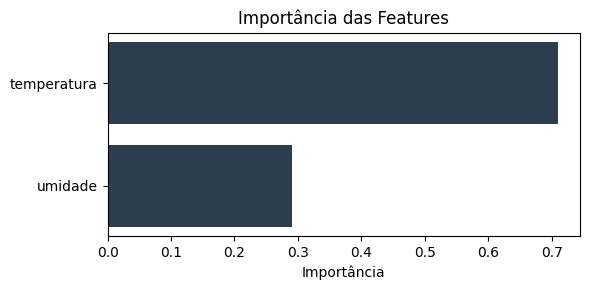

    feature  importancia
    umidade     0.290864
temperatura     0.709136


In [11]:
importancias = pd.DataFrame({
    'feature': ['temperatura', 'umidade'],
    'importancia': tree_model.feature_importances_
}).sort_values('importancia', ascending=True)

fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(importancias['feature'], importancias['importancia'], color='#2c3e50')
ax.set_xlabel('Importância')
ax.set_title('Importância das Features')
plt.tight_layout()
plt.show()

print(importancias.to_string(index=False))

## 8. Comparação: Regras (Aula 3) vs. Decision Tree

Aplicamos ambos os sistemas nos mesmos dados de teste para comparar as classificações.

In [12]:
from dataclasses import dataclass
from typing import Callable, Dict, List


@dataclass
class Rule:
    name: str
    condition: Callable[[Dict], bool]
    label: str


def classify_rules(row, rules: List[Rule]):
    for r in rules:
        if r.condition(row):
            return r.label
    return 'Confortável'


# Regras da Aula 3 (limiares originais)
rules = [
    Rule('Frio',    lambda r: r['temperatura'] < 10,  'Frio'),
    Rule('Quente',  lambda r: r['temperatura'] > 35,  'Quente'),
    Rule('Seco',    lambda r: r['umidade'] < 30,      'Seco'),
    Rule('Úmido',   lambda r: r['umidade'] > 80,      'Úmido'),
]

# Aplicar regras no mesmo conjunto de teste
y_rules = X_test.apply(lambda row: classify_rules(row, rules), axis=1)
y_tree = pd.Series(y_pred, index=y_test.index)

acc_rules = accuracy_score(y_test, y_rules)
acc_tree = accuracy_score(y_test, y_tree)

print(f'Acurácia — Sistema de Regras (Aula 3): {acc_rules:.4f}')
print(f'Acurácia — Decision Tree:               {acc_tree:.4f}')
print(f'\nDiferença: {(acc_tree - acc_rules)*100:+.2f} pontos percentuais')

Acurácia — Sistema de Regras (Aula 3): 0.5500
Acurácia — Decision Tree:               0.8733

Diferença: +32.33 pontos percentuais


In [13]:
# Onde os dois sistemas discordam?
discordancias = pd.DataFrame({
    'temperatura': X_test['temperatura'].values,
    'umidade': X_test['umidade'].values,
    'real': y_test.values,
    'regras': y_rules.values,
    'decision_tree': y_tree.values
})
discordancias = discordancias[
    discordancias['regras'] != discordancias['decision_tree']
]

print(f'Quantidade de discordâncias: {len(discordancias)} de {len(y_test)} amostras')
print(f'\nExemplos de discordâncias:')
discordancias.head(15)

Quantidade de discordâncias: 224 de 600 amostras

Exemplos de discordâncias:


,temperatura,umidade,real,regras,decision_tree
0,33.2,62.8,Quente,Confortável,Quente
2,32.7,41.7,Quente,Confortável,Quente
7,31.6,73.6,Quente,Confortável,Quente
10,10.0,66.7,Confortável,Confortável,Frio
12,12.7,34.2,Frio,Confortável,Frio
14,31.4,68.8,Quente,Confortável,Quente
15,33.2,56.0,Quente,Confortável,Quente
16,30.3,40.0,Quente,Confortável,Quente
22,34.9,26.6,Seco,Seco,Quente
23,32.9,70.0,Quente,Confortável,Quente


## 9. Discussão Final

| Aspecto | Sistema de Regras | Decision Tree |
|---|---|---|
| **Base dos limiares** | Definidos manualmente pelo especialista | Aprendidos automaticamente a partir dos dados |
| **Granularidade** | Limiares rígidos e poucos (temp < 10, > 35) | Limiares refinados e múltiplos (a árvore encontra cortes ótimos) |
| **Zona de conforto ASHRAE** | Não implementada diretamente | Consegue aproximar a zona 20-26°C / 30-60% |
| **Transparência** | Total — cada regra é explícita | Alta — a árvore pode ser visualizada e interpretada |
| **Escalabilidade** | Difícil com muitas variáveis | Escala naturalmente para mais features (CLO, MET, Vair) |
| **Manutenção** | Requer reescrita manual de regras | Retreinar com novos dados |
| **Risco de overfitting** | Nenhum — regras são fixas | Possível se `max_depth` for muito alto |

### Conclusão

A árvore de decisão aprende limiares muito mais próximos da norma ASHRAE 55 do que as regras manuais da Aula 3, que usavam cortes excessivamente extremos (10°C e 35°C). Além disso, a árvore é escalável: basta adicionar variáveis como velocidade do ar (Vair) e vestimenta (CLO) para obter classificações mais precisas, sem reescrever regras manualmente.

Ambas as abordagens mantêm a vantagem de **interpretabilidade**, mas a Decision Tree oferece o melhor equilíbrio entre transparência e capacidade de aprendizado automático.